100%|██████████| 182M/182M [00:06<00:00, 29.3MB/s] 


100%|██████████| 64.3M/64.3M [00:04<00:00, 14.4MB/s]


Epoch [1/100] - Loss: 0.8392, Test Accuracy: 87.38%
Epoch [2/100] - Loss: 0.4084, Test Accuracy: 89.51%
Epoch [3/100] - Loss: 0.3428, Test Accuracy: 90.65%
Epoch [4/100] - Loss: 0.3023, Test Accuracy: 91.07%
Epoch [5/100] - Loss: 0.2717, Test Accuracy: 91.98%
Epoch [6/100] - Loss: 0.2513, Test Accuracy: 92.22%
Epoch [7/100] - Loss: 0.2324, Test Accuracy: 92.30%
Epoch [8/100] - Loss: 0.2140, Test Accuracy: 92.69%
Epoch [9/100] - Loss: 0.1978, Test Accuracy: 93.01%
Epoch [10/100] - Loss: 0.1858, Test Accuracy: 93.16%
Epoch [11/100] - Loss: 0.1751, Test Accuracy: 93.59%
Epoch [12/100] - Loss: 0.1633, Test Accuracy: 93.34%
Epoch [13/100] - Loss: 0.1522, Test Accuracy: 93.60%
Epoch [14/100] - Loss: 0.1437, Test Accuracy: 93.82%
Epoch [15/100] - Loss: 0.1373, Test Accuracy: 93.75%
Epoch [16/100] - Loss: 0.1288, Test Accuracy: 93.74%
Epoch [17/100] - Loss: 0.1257, Test Accuracy: 93.77%
Epoch [18/100] - Loss: 0.1165, Test Accuracy: 93.58%
Epoch [19/100] - Loss: 0.1119, Test Accuracy: 93.64%
Ep

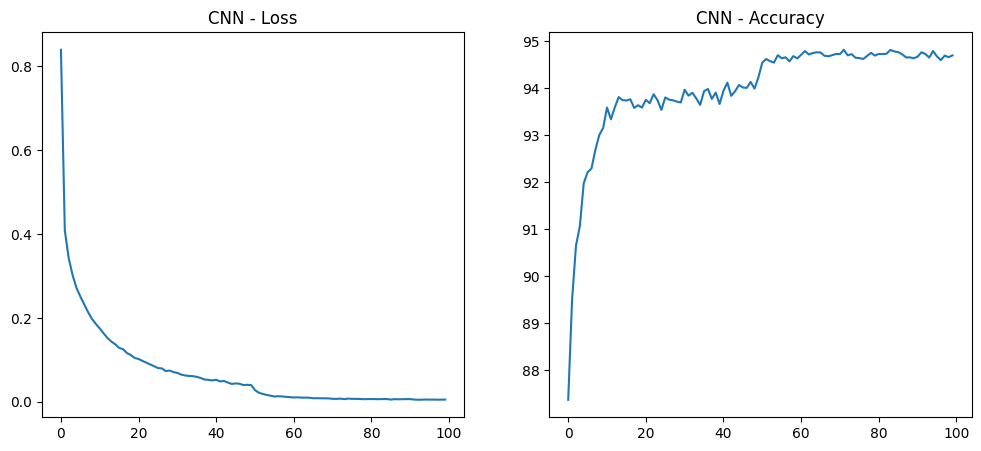

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728],
                         std=[0.1980, 0.2010, 0.1970])
])

trainset = SVHN(root='./data', split='train', download=True, transform=transform)
testset = SVHN(root='./data', split='test', download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=1000, shuffle=False, num_workers=2)

# CNN Model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Training Function
def train(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

# Testing Function
def test(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
def run_training(model_class, num_epochs=100):
    model = model_class().cuda()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

    train_losses, test_accuracies = [], []
    for epoch in range(num_epochs):
        train_loss, train_acc = train(model, trainloader, optimizer, criterion)
        test_acc = test(model, testloader)
        train_losses.append(train_loss)
        test_accuracies.append(test_acc)
        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {train_loss:.4f}, Test Accuracy: {test_acc:.2f}%")
    return model, train_losses, test_accuracies

# Plotting Function
def plot_metrics(train_losses, test_accuracies, title="CNN"):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.title(f'{title} - Loss')
    plt.subplot(1, 2, 2)
    plt.plot(test_accuracies, label="Test Accuracy")
    plt.title(f'{title} - Accuracy')
    plt.show()

# Run CNN
cnn_model, cnn_losses, cnn_accuracies = run_training(CNNModel)
plot_metrics(cnn_losses, cnn_accuracies, "CNN")
